<a href="https://colab.research.google.com/github/narayanamalla/Financial-Modelling-of-ONGC/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

Using device: cpu


In [9]:
# Load CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [10]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        # Define the layers for the ANN
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)       # Output layer
    def forward(self, x):

        x = x.view(-1, 32*32*3)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [11]:
# Initialize the ANN model, loss function, and optimizer
model_ann = ANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_ann.parameters(), lr=0.001)

In [12]:
# Training loop
print("Training ANN...")
num_epochs = 5
ls_losses = []
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Move images and labels to the device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model_ann(images)
        loss = criterion(outputs, labels)
        ls_losses.append(loss.detach().cpu().numpy())

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

Training ANN...
Epoch [1/5], Step [100/782], Loss: 1.4565
Epoch [1/5], Step [200/782], Loss: 1.7897
Epoch [1/5], Step [300/782], Loss: 1.8212
Epoch [1/5], Step [400/782], Loss: 1.5294
Epoch [1/5], Step [500/782], Loss: 1.6329
Epoch [1/5], Step [600/782], Loss: 1.5052
Epoch [1/5], Step [700/782], Loss: 1.3601
Epoch [2/5], Step [100/782], Loss: 1.1936
Epoch [2/5], Step [200/782], Loss: 1.4581
Epoch [2/5], Step [300/782], Loss: 1.6423
Epoch [2/5], Step [400/782], Loss: 1.6227
Epoch [2/5], Step [500/782], Loss: 1.4242
Epoch [2/5], Step [600/782], Loss: 1.5809
Epoch [2/5], Step [700/782], Loss: 1.4011
Epoch [3/5], Step [100/782], Loss: 1.4641
Epoch [3/5], Step [200/782], Loss: 1.3190
Epoch [3/5], Step [300/782], Loss: 1.2551
Epoch [3/5], Step [400/782], Loss: 1.1726
Epoch [3/5], Step [500/782], Loss: 1.2428
Epoch [3/5], Step [600/782], Loss: 1.3113
Epoch [3/5], Step [700/782], Loss: 1.1868
Epoch [4/5], Step [100/782], Loss: 1.2844
Epoch [4/5], Step [200/782], Loss: 0.9689
Epoch [4/5], Step 

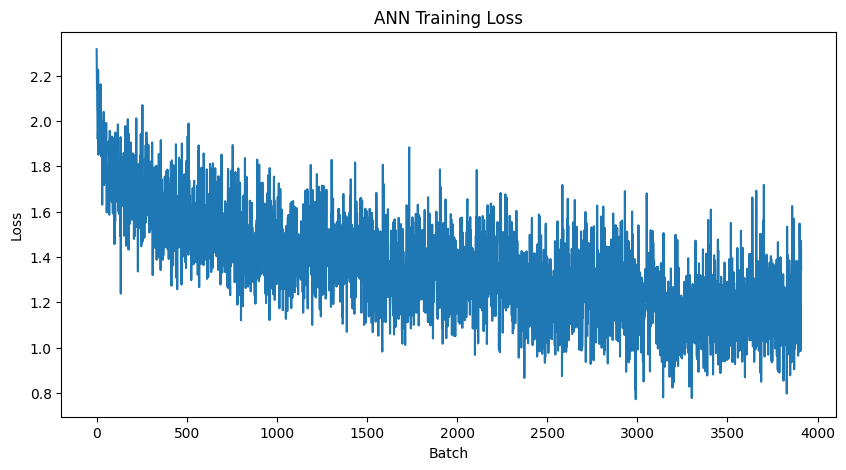

ANN Accuracy: 0.5231
ANN Precision: 0.5187
ANN Recall: 0.5231
ANN F1-Score: 0.5151


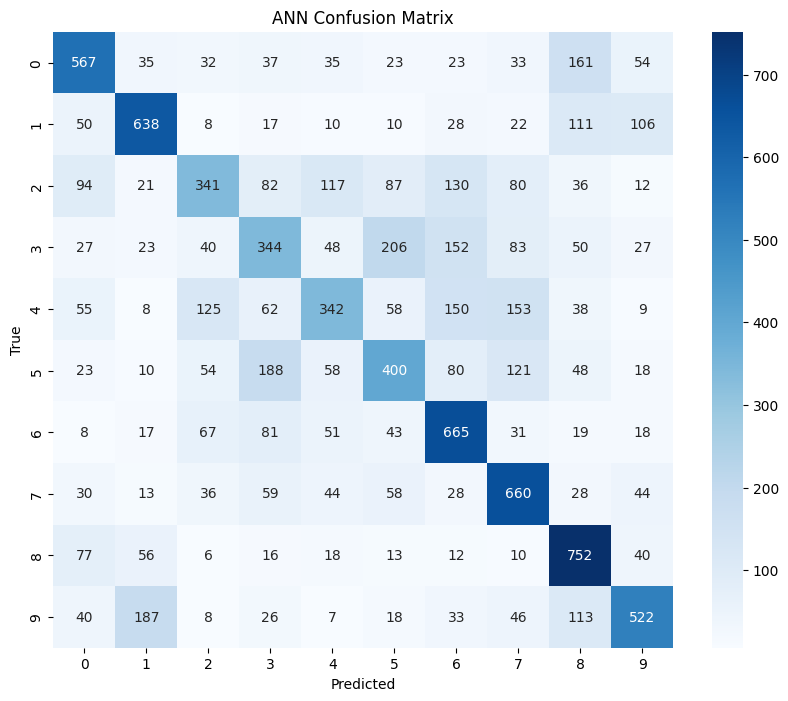

In [13]:
# Plot Losses
plt.figure(figsize=(10, 5))
x_axis = np.arange(0, len(ls_losses), 1)
plt.plot(x_axis, ls_losses)
plt.title('ANN Training Loss')
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.show()

# Test the model
model_ann.eval()
all_preds_ann = []
all_labels_ann = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model_ann(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_ann.extend(predicted.cpu().numpy())
        all_labels_ann.extend(labels.cpu().numpy())

# Calculate accuracy, precision, recall, and F1-score using sklearn
accuracy_ann = accuracy_score(all_labels_ann, all_preds_ann)
precision_ann = precision_score(all_labels_ann, all_preds_ann, average='macro')
recall_ann = recall_score(all_labels_ann, all_preds_ann, average='macro')
f1_ann = f1_score(all_labels_ann, all_preds_ann, average='macro')

print(f"ANN Accuracy: {accuracy_ann:.4f}")
print(f"ANN Precision: {precision_ann:.4f}")
print(f"ANN Recall: {recall_ann:.4f}")
print(f"ANN F1-Score: {f1_ann:.4f}")

# Confusion Matrix for ANN
cm_ann = confusion_matrix(all_labels_ann, all_preds_ann)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ANN Confusion Matrix')
plt.show()

In [14]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Define the CNN layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # After two pooling layers (32x32 -> 16x16 -> 8x8), the feature map size is 8x8 with 64 channels.
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)  # Output layer for 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)  # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [15]:
# Initialize the CNN model, loss function, and optimizer
model_cnn = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)

print("Training CNN...")
# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model_cnn(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

Training CNN...
Epoch [1/5], Step [100/782], Loss: 1.7228
Epoch [1/5], Step [200/782], Loss: 1.5223
Epoch [1/5], Step [300/782], Loss: 1.3095
Epoch [1/5], Step [400/782], Loss: 1.1284
Epoch [1/5], Step [500/782], Loss: 1.2357
Epoch [1/5], Step [600/782], Loss: 1.0092
Epoch [1/5], Step [700/782], Loss: 1.0816
Epoch [2/5], Step [100/782], Loss: 0.9119
Epoch [2/5], Step [200/782], Loss: 1.1147
Epoch [2/5], Step [300/782], Loss: 0.9152
Epoch [2/5], Step [400/782], Loss: 0.8746
Epoch [2/5], Step [500/782], Loss: 0.9271
Epoch [2/5], Step [600/782], Loss: 0.7381
Epoch [2/5], Step [700/782], Loss: 1.0129
Epoch [3/5], Step [100/782], Loss: 0.8681
Epoch [3/5], Step [200/782], Loss: 0.6262
Epoch [3/5], Step [300/782], Loss: 0.5555
Epoch [3/5], Step [400/782], Loss: 0.6709
Epoch [3/5], Step [500/782], Loss: 0.6769
Epoch [3/5], Step [600/782], Loss: 0.6973
Epoch [3/5], Step [700/782], Loss: 0.7301
Epoch [4/5], Step [100/782], Loss: 0.4799
Epoch [4/5], Step [200/782], Loss: 0.4746
Epoch [4/5], Step 

CNN Accuracy: 0.7378
CNN Precision: 0.7411
CNN Recall: 0.7378
CNN F1-Score: 0.7361


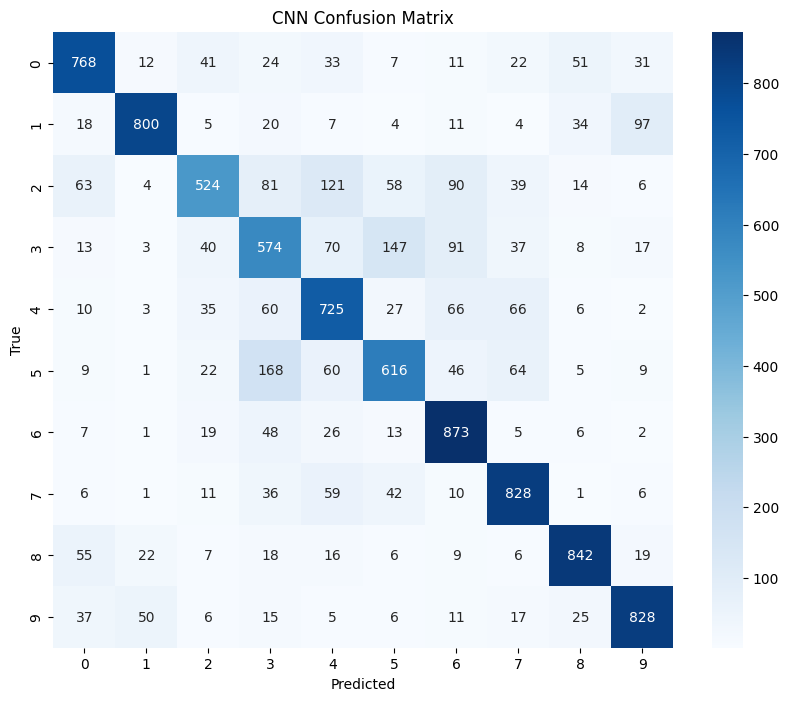

In [16]:
# Test the CNN model
model_cnn.eval()
all_preds_cnn = []
all_labels_cnn = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_cnn(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_cnn.extend(predicted.cpu().numpy())
        all_labels_cnn.extend(labels.cpu().numpy())

# Calculate accuracy, precision, recall, and F1-score for the CNN
accuracy_cnn = accuracy_score(all_labels_cnn, all_preds_cnn)
precision_cnn = precision_score(all_labels_cnn, all_preds_cnn, average='macro')
recall_cnn = recall_score(all_labels_cnn, all_preds_cnn, average='macro')
f1_cnn = f1_score(all_labels_cnn, all_preds_cnn, average='macro')

print(f"CNN Accuracy: {accuracy_cnn:.4f}")
print(f"CNN Precision: {precision_cnn:.4f}")
print(f"CNN Recall: {recall_cnn:.4f}")
print(f"CNN F1-Score: {f1_cnn:.4f}")

# Confusion Matrix for CNN
cm_cnn = confusion_matrix(all_labels_cnn, all_preds_cnn)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN Confusion Matrix')
plt.show()

In [17]:
import pandas as pd

# Create a comparison table
data = {
    'Model': ['ANN', 'CNN'],
    'Accuracy': [accuracy_ann, accuracy_cnn],
    'Precision': [precision_ann, precision_cnn],
    'Recall': [recall_ann, recall_cnn],
    'F1-Score': [f1_ann, f1_cnn]
}

df_comparison = pd.DataFrame(data)
print(df_comparison)

  Model  Accuracy  Precision  Recall  F1-Score
0   ANN    0.5231   0.518735  0.5231  0.515100
1   CNN    0.7378   0.741073  0.7378  0.736105


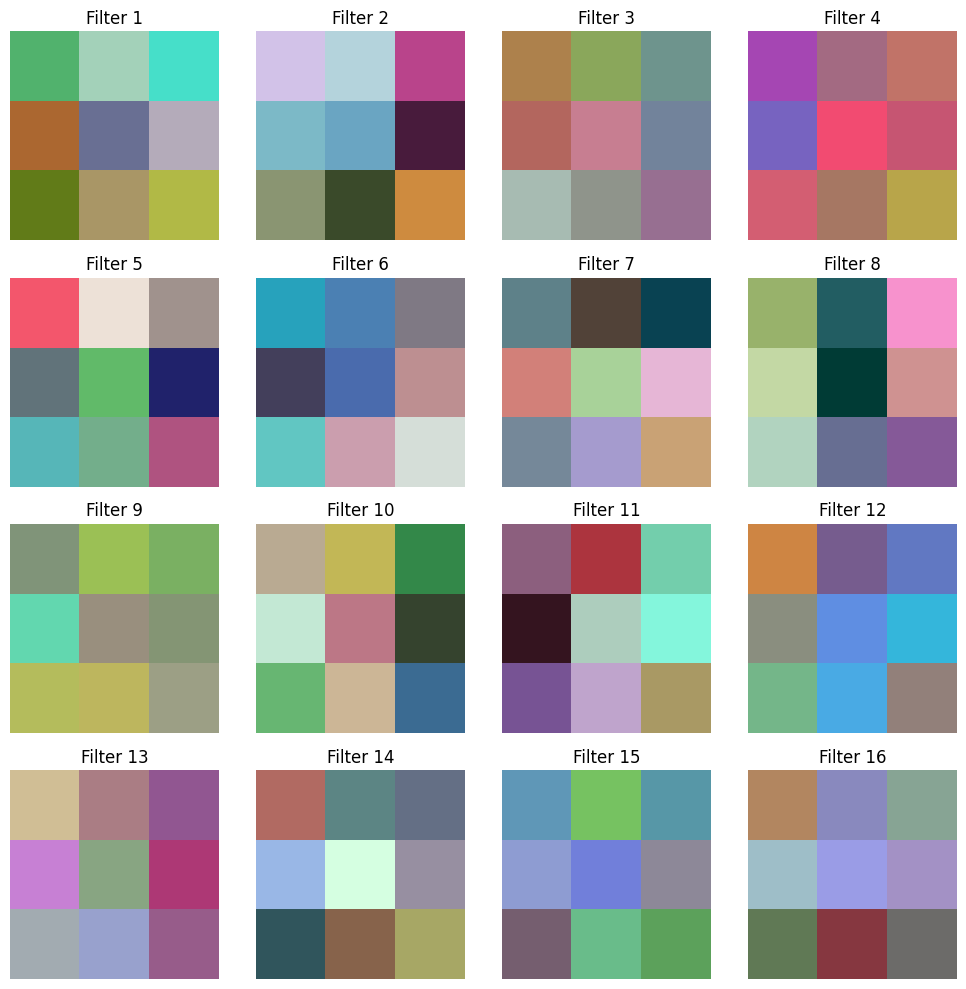

In [18]:
# Visualize filters from the first convolutional layer of the CNN model
first_conv_layer_weights = model_cnn.conv1.weight.data.cpu().numpy()

# Normalize the weights for visualization
min_w = np.min(first_conv_layer_weights)
max_w = np.max(first_conv_layer_weights)
first_conv_layer_weights = (first_conv_layer_weights - min_w) / (max_w - min_w)

# Plot the filters
num_filters = first_conv_layer_weights.shape[0]
num_plots = min(num_filters, 16)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
axes = axes.flatten()

for i in range(num_plots):
    # Transpose from (C, H, W) to (H, W, C) for displaying
    filter_img = first_conv_layer_weights[i].transpose((1, 2, 0))
    axes[i].imshow(filter_img)
    axes[i].set_title(f'Filter {i+1}')
    axes[i].axis('off')

# Hide unused subplots
for j in range(num_plots, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Define data augmentation transformations
train_transform_augmented = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 dataset with data augmentation
train_dataset_augmented = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                      download=True, transform=train_transform_augmented)
# Use the original transform for testing
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_loader_augmented = DataLoader(dataset=train_dataset_augmented, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

# Initialize CNN model, loss function, and optimizer
model_cnn_augmented = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_augmented = optim.Adam(model_cnn_augmented.parameters(), lr=0.001)

print("Training CNN with Data Augmentation...")

# Train the CNN model
num_epochs = 5
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader_augmented):
        # Move images and labels to the device
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model_cnn_augmented(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer_augmented.zero_grad()
        loss.backward()
        optimizer_augmented.step()

        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader_augmented)}], Loss: {loss.item():.4f}")

Training CNN with Data Augmentation...
Epoch [1/5], Step [100/782], Loss: 1.7982
Epoch [1/5], Step [200/782], Loss: 1.6901
Epoch [1/5], Step [300/782], Loss: 1.5006
Epoch [1/5], Step [400/782], Loss: 1.4238
Epoch [1/5], Step [500/782], Loss: 1.4726
Epoch [1/5], Step [600/782], Loss: 1.2584
Epoch [1/5], Step [700/782], Loss: 1.2290
Epoch [2/5], Step [100/782], Loss: 1.3357
Epoch [2/5], Step [200/782], Loss: 1.0912
Epoch [2/5], Step [300/782], Loss: 0.9921
Epoch [2/5], Step [400/782], Loss: 1.1135
Epoch [2/5], Step [500/782], Loss: 1.1790
Epoch [2/5], Step [600/782], Loss: 1.1477
Epoch [2/5], Step [700/782], Loss: 1.0585
Epoch [3/5], Step [100/782], Loss: 0.9289
Epoch [3/5], Step [200/782], Loss: 1.0986
Epoch [3/5], Step [300/782], Loss: 1.0155
Epoch [3/5], Step [400/782], Loss: 1.0507
Epoch [3/5], Step [500/782], Loss: 1.0027


In [ ]:
# Visualize some incorrect predictions from the augmented CNN model
model_to_evaluate = model_cnn_augmented
model_to_evaluate.eval()

incorrect_preds = []
incorrect_labels = []
incorrect_images = []

# CIFAR-10 classes for labeling the plots
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

with torch.no_grad():
    for images, labels in test_loader:
        images_cpu = images.cpu()
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model_to_evaluate(images)
        _, predicted = torch.max(outputs.data, 1)

        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                incorrect_preds.append(predicted[i].item())
                incorrect_labels.append(labels[i].item())
                # Denormalize the image before storing
                img = images_cpu[i].numpy().transpose((1, 2, 0))
                img = 0.5 * img + 0.5 # Denormalize from [-1, 1] to [0, 1]
                img = np.clip(img, 0, 1)
                incorrect_images.append(img)

# Display up to 10 incorrect predictions
num_to_display = min(len(incorrect_images), 10)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 6))
axes = axes.flatten()

if num_to_display > 0:
    for i in range(num_to_display):
        axes[i].imshow(incorrect_images[i])
        pred_class = classes[incorrect_preds[i]]
        true_class = classes[incorrect_labels[i]]
        axes[i].set_title(f'Pred: {pred_class}\nTrue: {true_class}')
        axes[i].axis('off')

    # Hide unused subplots
    for j in range(num_to_display, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No incorrect predictions to display.")